In [1]:
import sys, os, torch, random
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader
from omegaconf import OmegaConf

warnings = __import__('warnings')
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../../..'))


In [2]:
from DL.models.custom_classifier_from_config import CustomClassifierFromConfig
from DL.trainers.model_trainer import ModelTrainer
from DL.data.synthetic_cyrillic_dataset import SyntheticCyrillicDataset
from DL.loggers.experiment_logger import ExperimentLogger
from DL.visualization.visualizer import ExperimentVisualizer

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) # Фиксируем сид

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [5]:
# Инициализация инфраструктуры
experiment_name = "lenet_4kb_vs_2kb_bg_loss_without_augmentations"
logger = ExperimentLogger(experiment_name, base_dir=".")
visualizer = ExperimentVisualizer(logger)

In [6]:
train_dataset = SyntheticCyrillicDataset(60000, 42)
test_dataset = SyntheticCyrillicDataset(15000, 999)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [7]:
def run_test(config_name: str, model_tag: str, use_bg: bool, alpha: float = 0.0):
    config_path = f'../../../DL/configs/lenet/{config_name}'
    conf = OmegaConf.load(config_path)
    conf.num_classes = len(train_dataset.char_to_idx)

    logger.save_config(OmegaConf.to_container(conf), filename=f"config_{model_tag}.json")
    logger.log(f"=== Запуск: {model_tag} | BG Loss: {use_bg} ===")

    model = CustomClassifierFromConfig(OmegaConf.to_container(conf)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    trainer = ModelTrainer(
        model=model, optimizer=optimizer, criterion=nn.CrossEntropyLoss(), device=device,
        use_background_loss=use_bg, bg_loss_alpha=alpha, bg_loss_n=2,
        logger=logger, visualizer=visualizer, model_name=model_tag
    )

    trainer.fit(train_loader, test_loader, epochs=5)

    return model

# Обучение 4KB модели без аугментаций и без bg loss

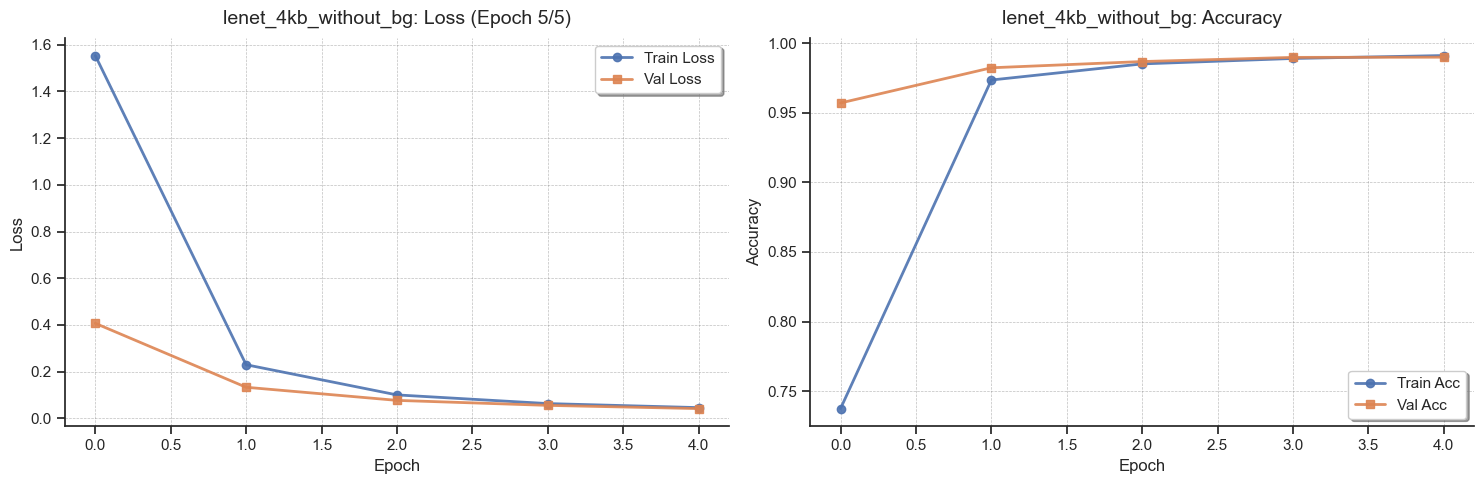

In [8]:
model_4kb_without_bg = run_test('lenet_4kb.json', model_tag="lenet_4kb_without_bg", use_bg=False)

## Блок визуализации 4KB (без bg loss)

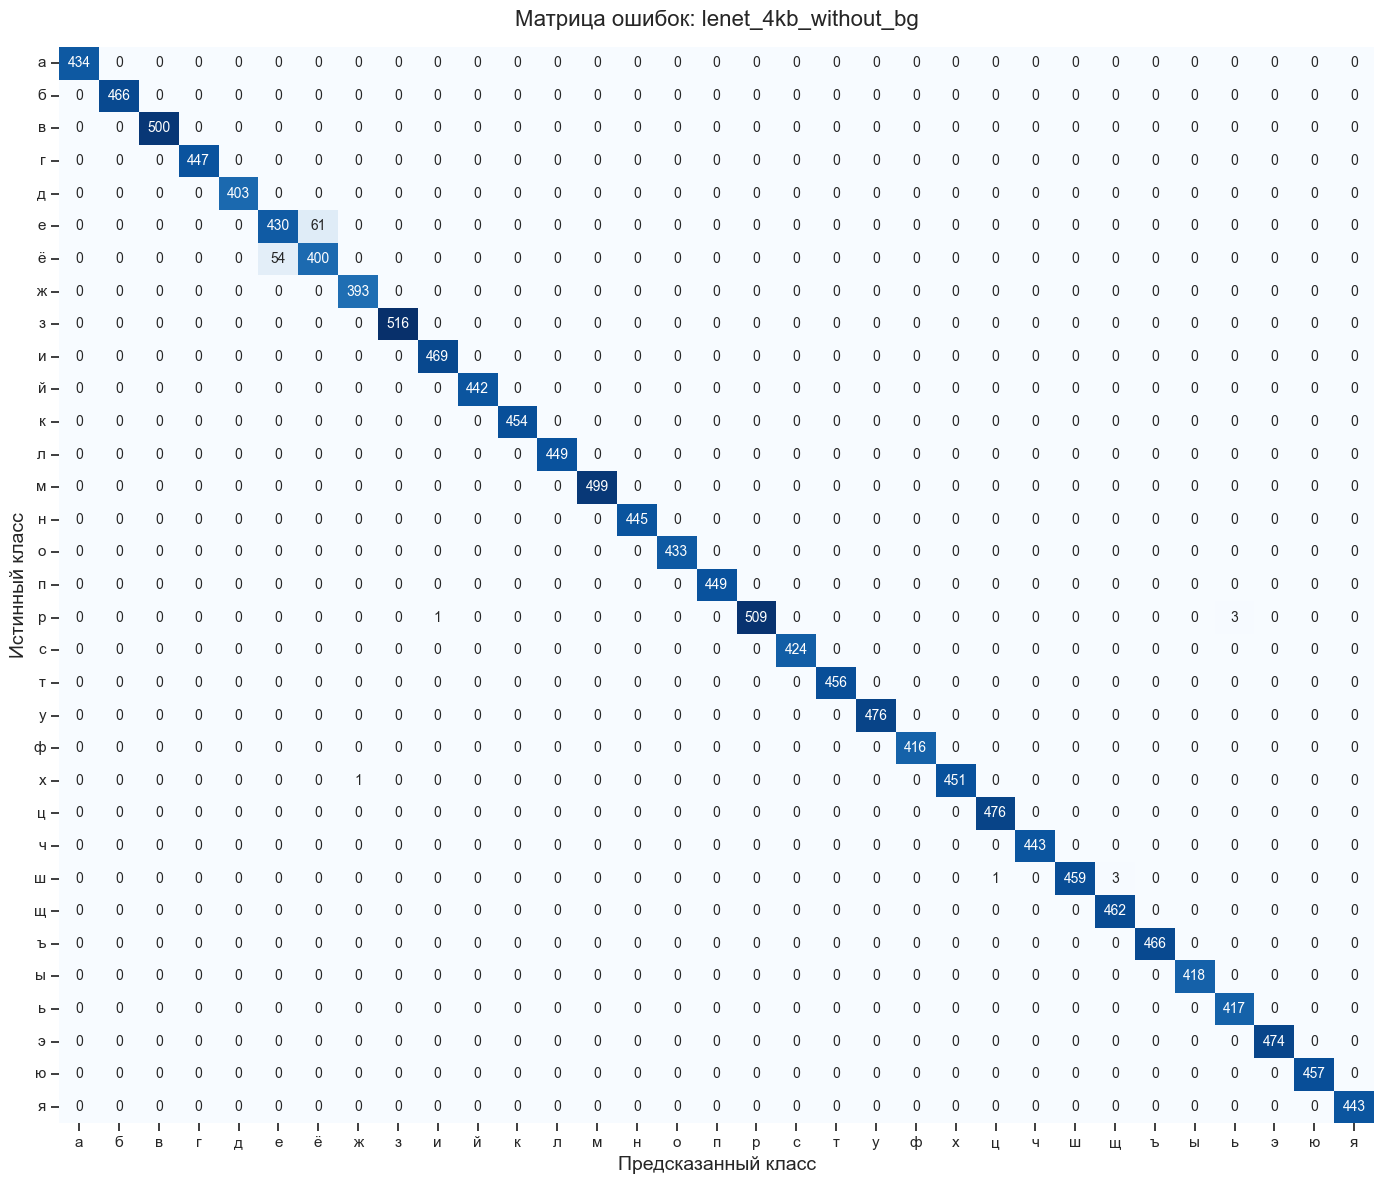

In [9]:
visualizer.plot_confusion_matrix(model_4kb_without_bg, test_loader, test_dataset, device, model_name="lenet_4kb_without_bg")

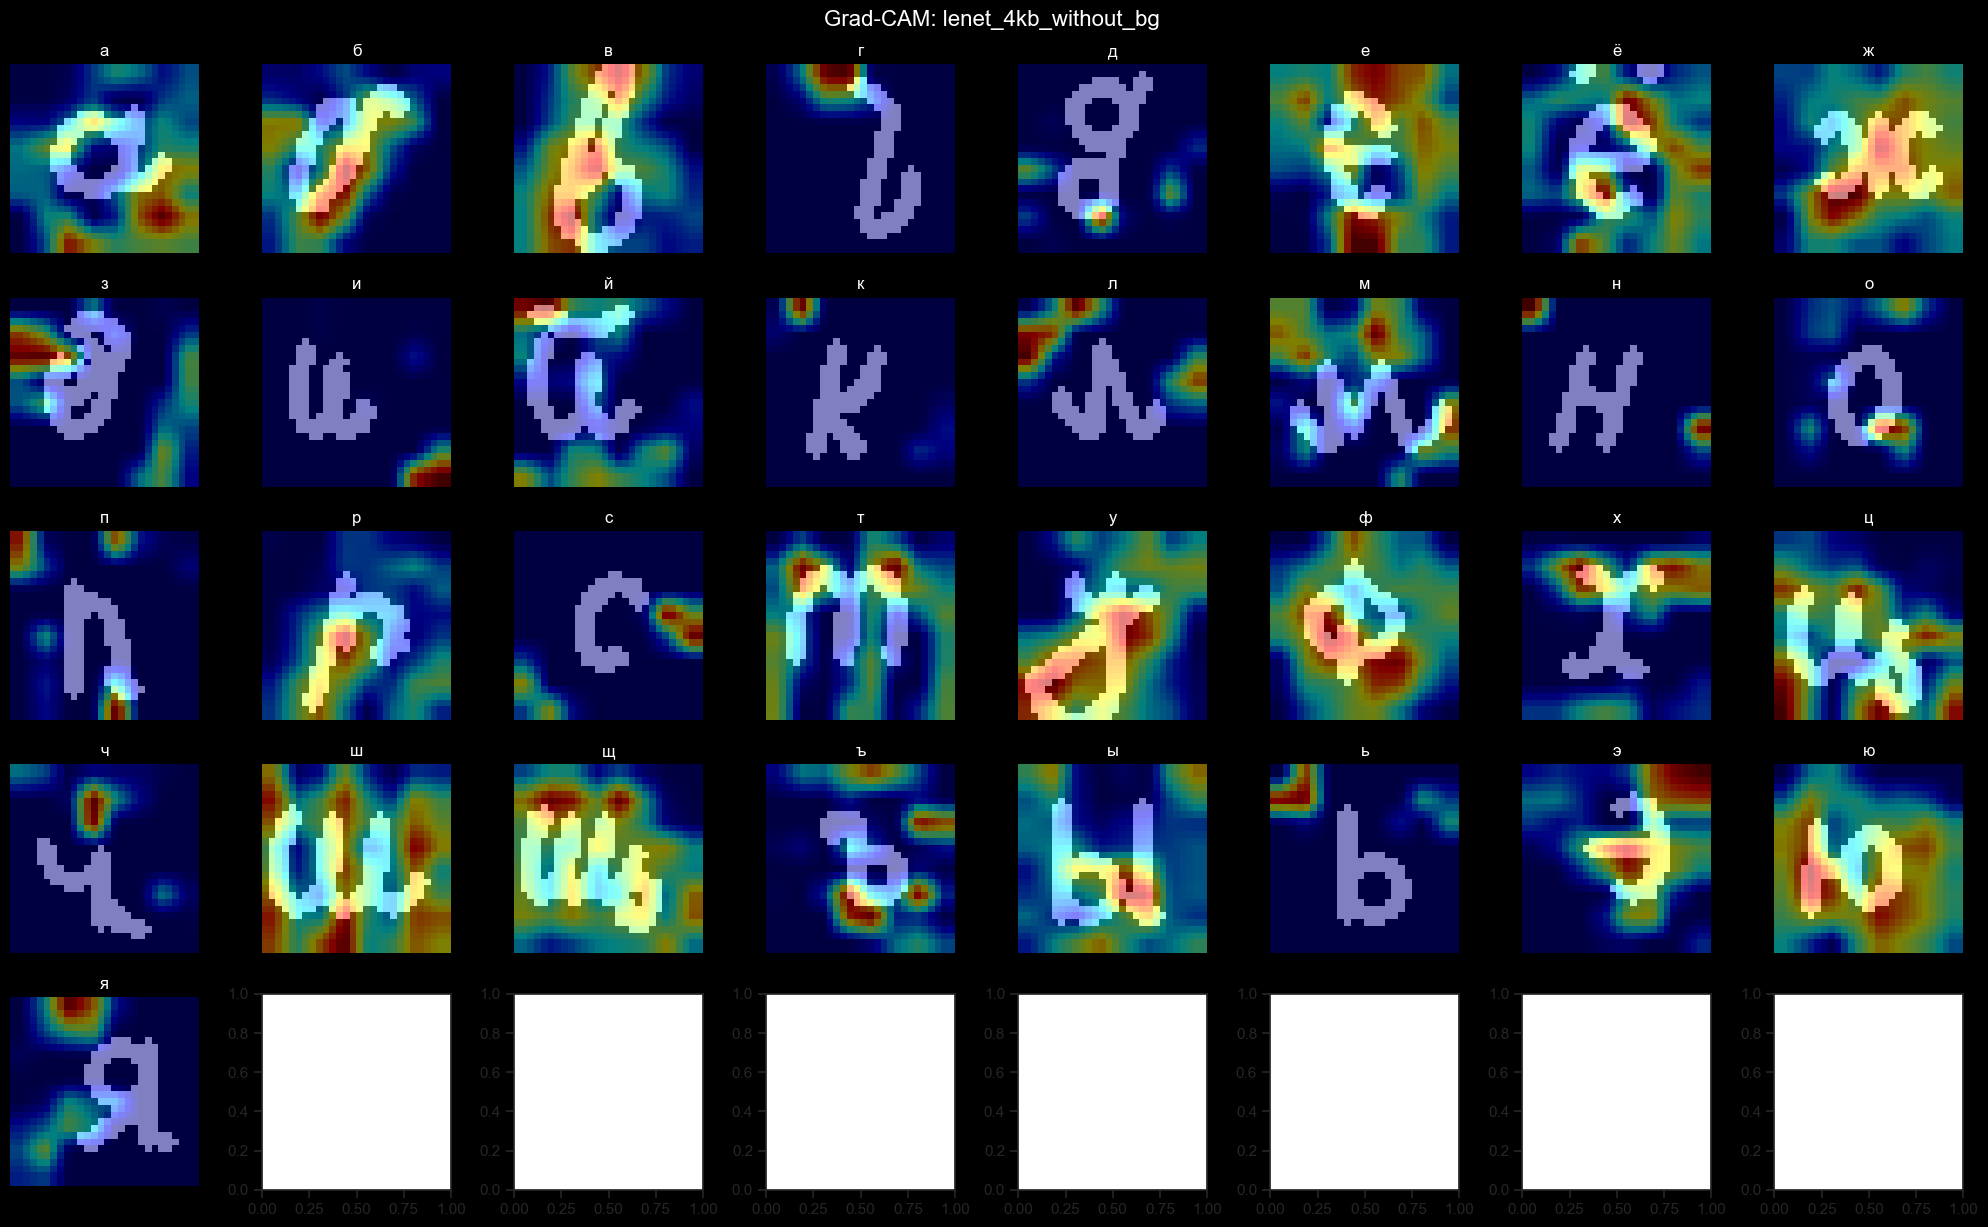

<Figure size 640x480 with 0 Axes>

In [10]:
visualizer.plot_gradcam(model_4kb_without_bg, test_dataset, device, model_name="lenet_4kb_without_bg")

# Обучение 4KB модели с bg loss

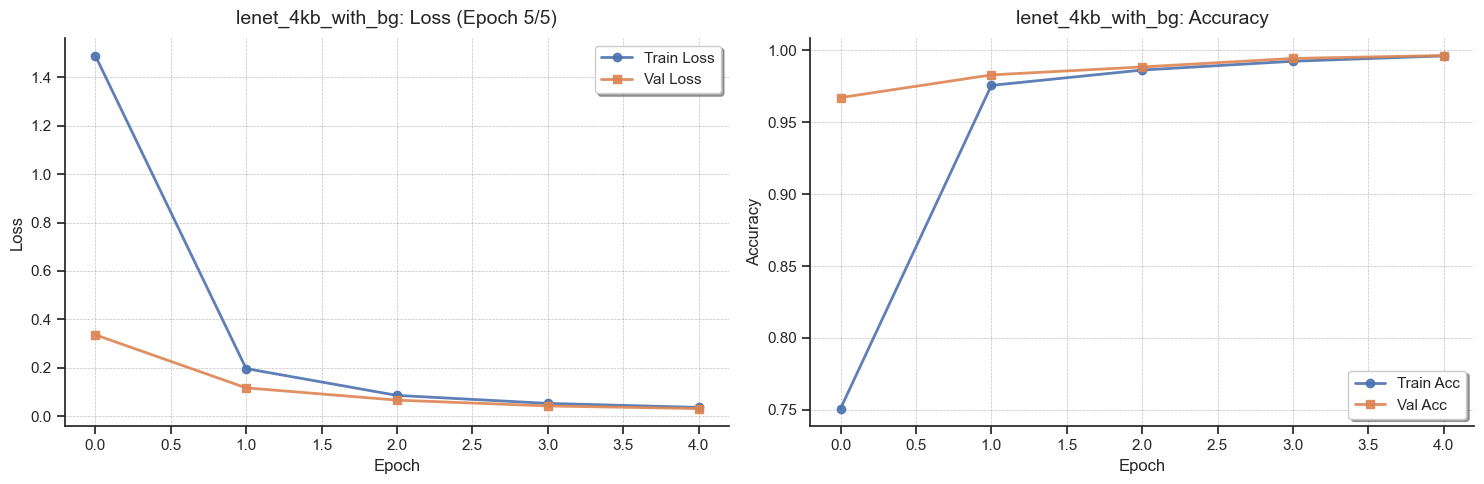

In [11]:
model_4kb_with_bg = run_test('lenet_4kb.json', model_tag="lenet_4kb_with_bg", use_bg=True, alpha=15.0)

## Блок визуализации 4KB (с bg loss)

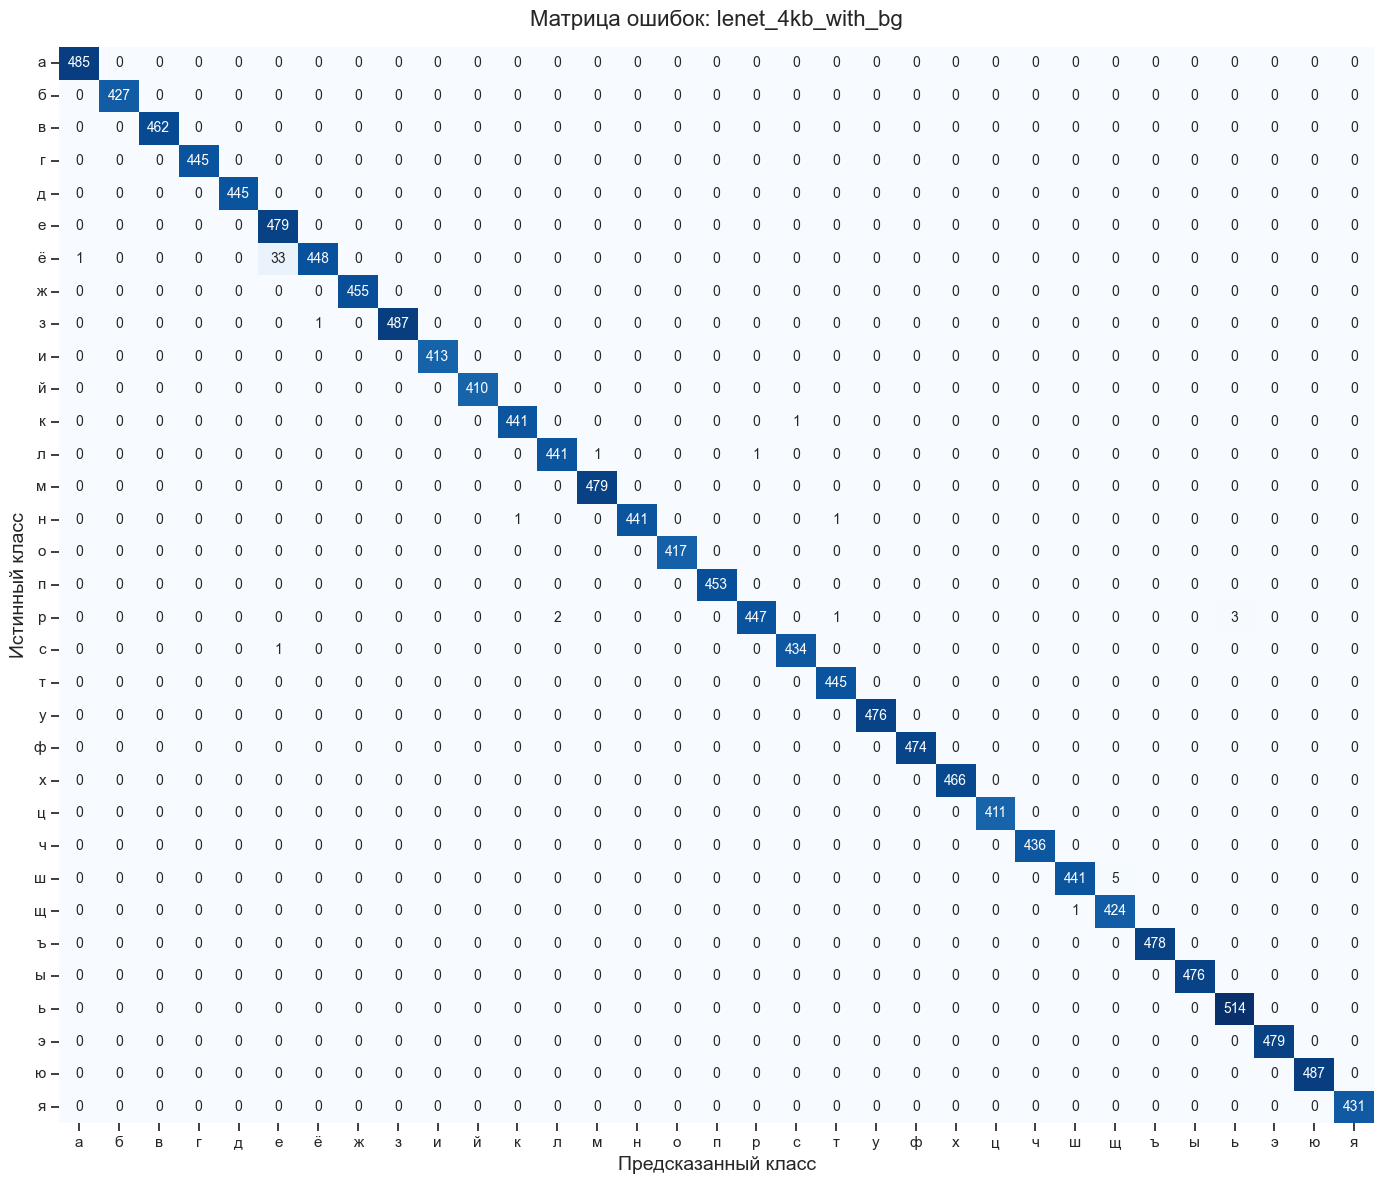

In [12]:
visualizer.plot_confusion_matrix(model_4kb_with_bg, test_loader, test_dataset, device, model_name="lenet_4kb_with_bg")

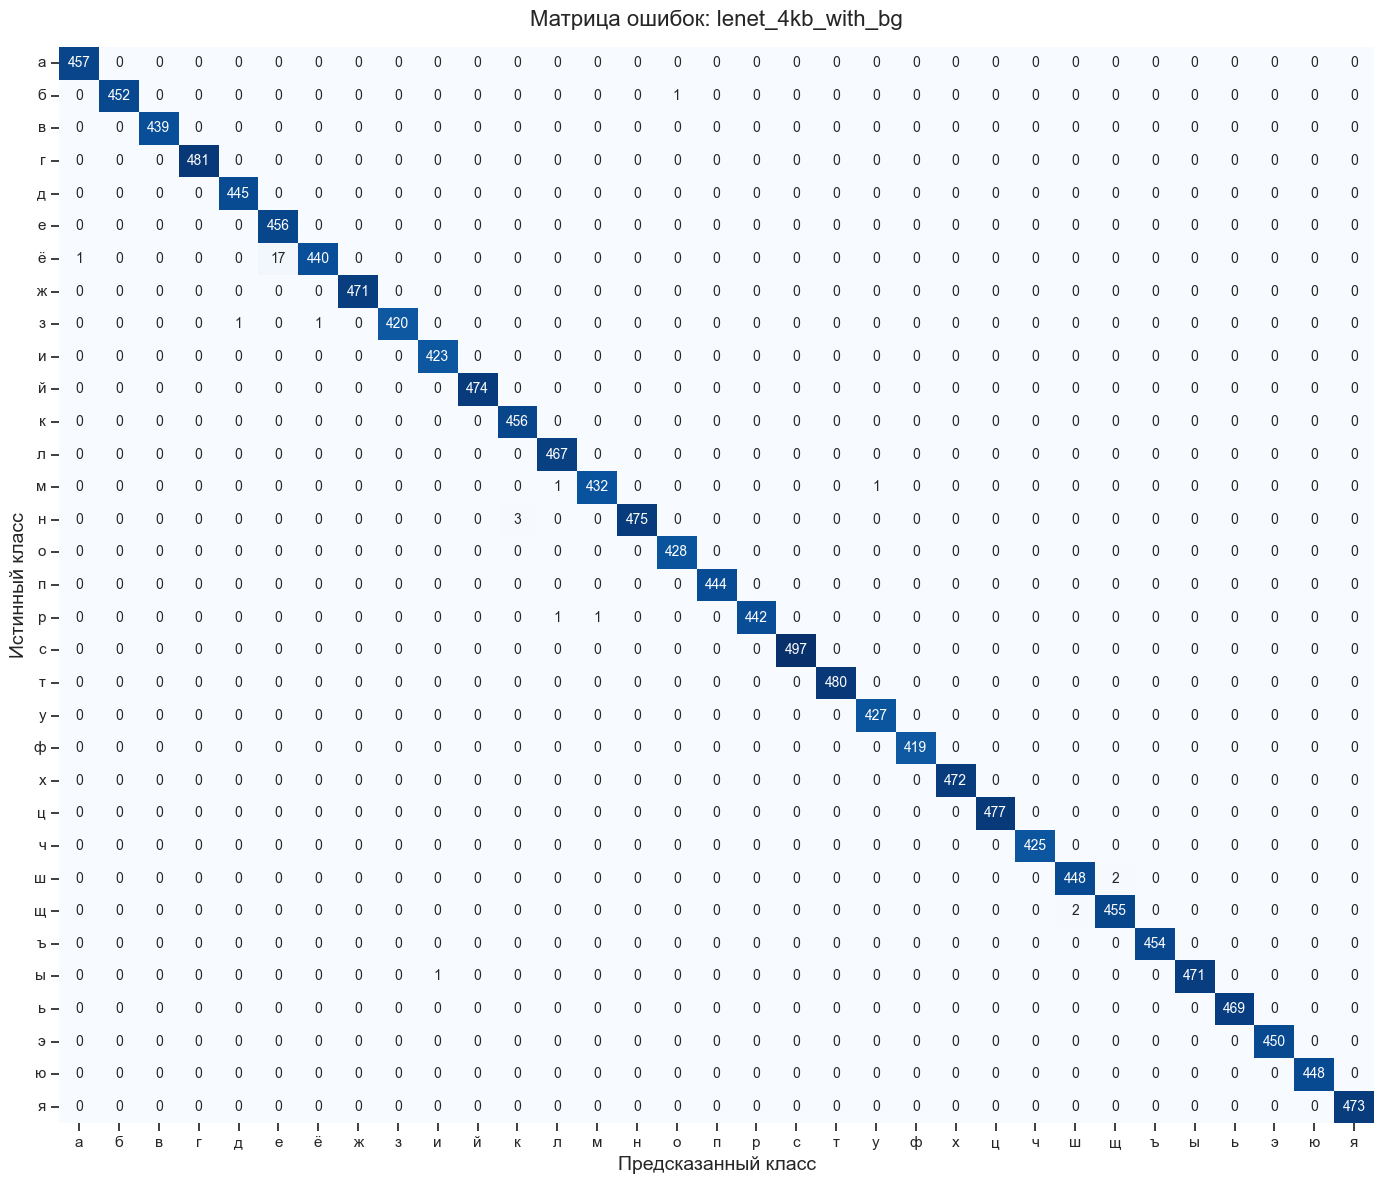

In [13]:
visualizer.plot_confusion_matrix(model_4kb_with_bg, test_loader, test_dataset, device, model_name="lenet_4kb_with_bg")

# Обучение 2KB модели без аугментаций и без bg loss

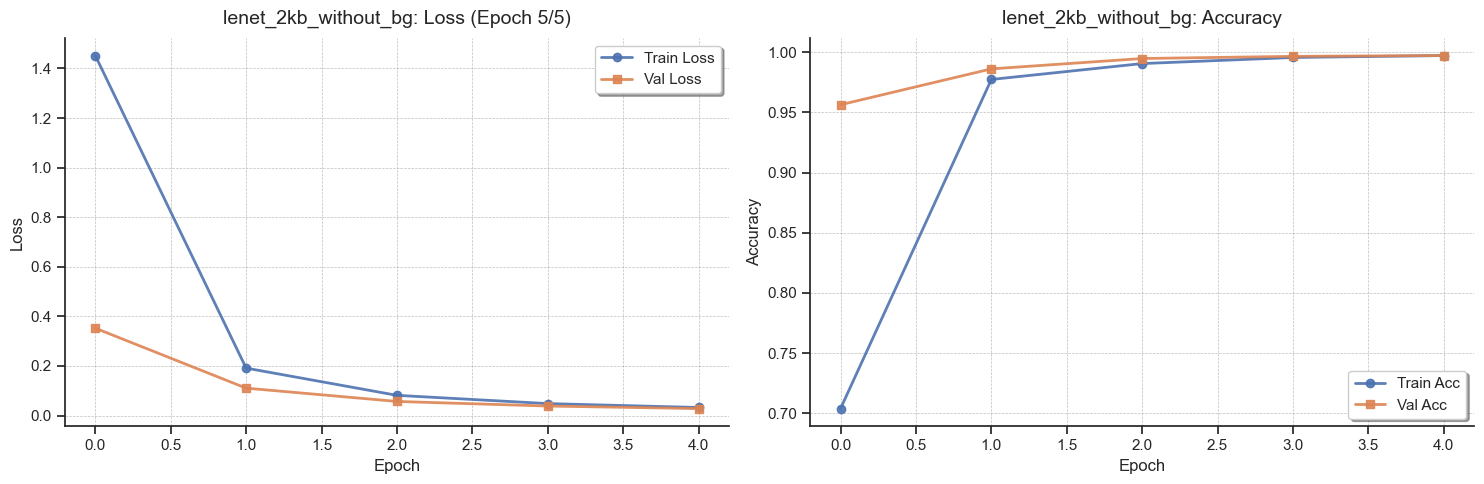

In [14]:
model_2kb_without_bg = run_test('lenet_2kb.json', model_tag="lenet_2kb_without_bg", use_bg=False)

## Блок визуализации 2KB (без bg loss)

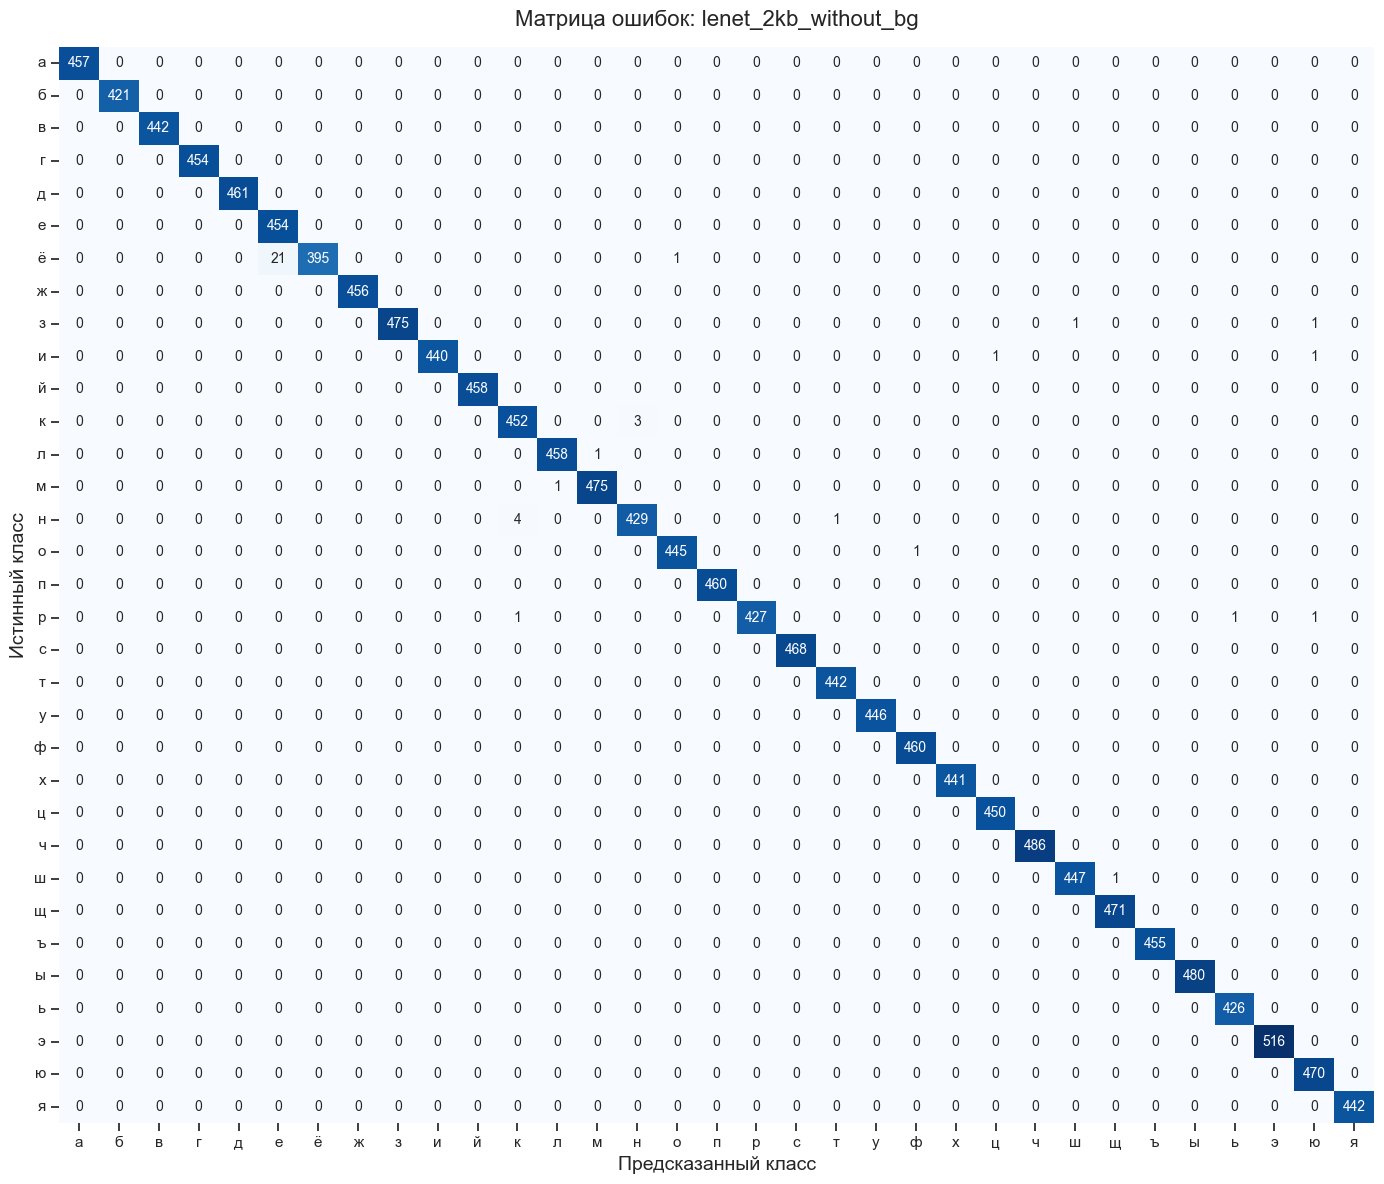

In [15]:
visualizer.plot_confusion_matrix(model_2kb_without_bg, test_loader, test_dataset, device, model_name="lenet_2kb_without_bg")

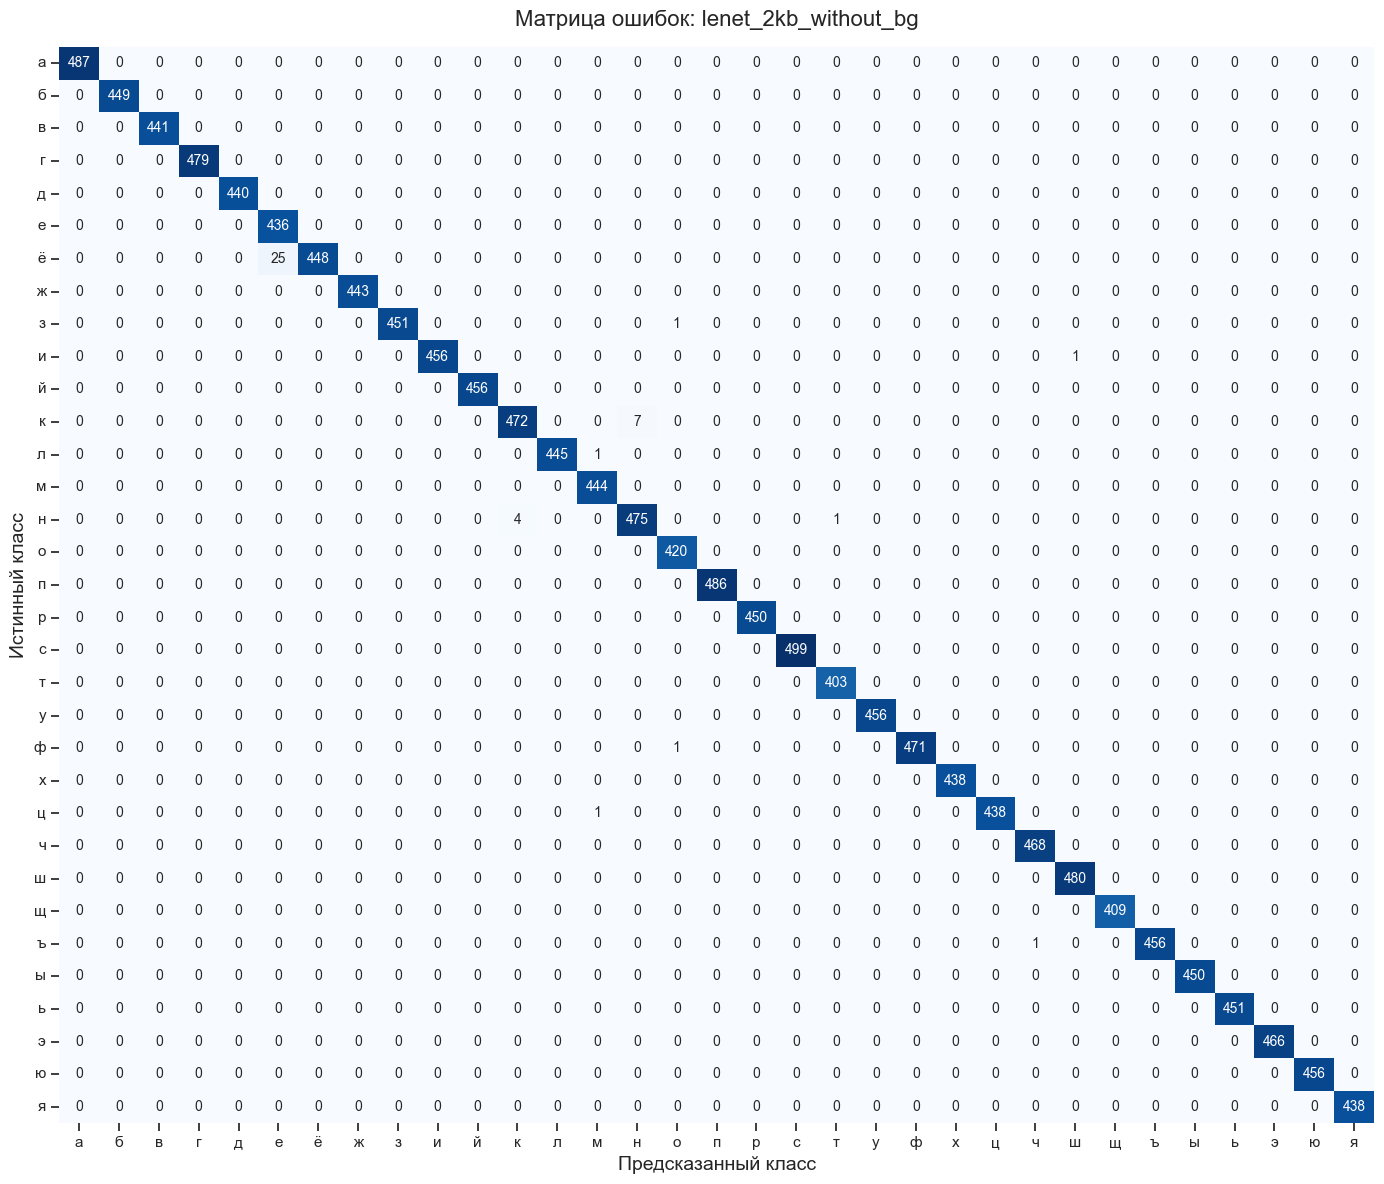

In [16]:
visualizer.plot_confusion_matrix(model_2kb_without_bg, test_loader, test_dataset, device, model_name="lenet_2kb_without_bg")

# Обучение 2KB модели без аугментаций и с bg loss

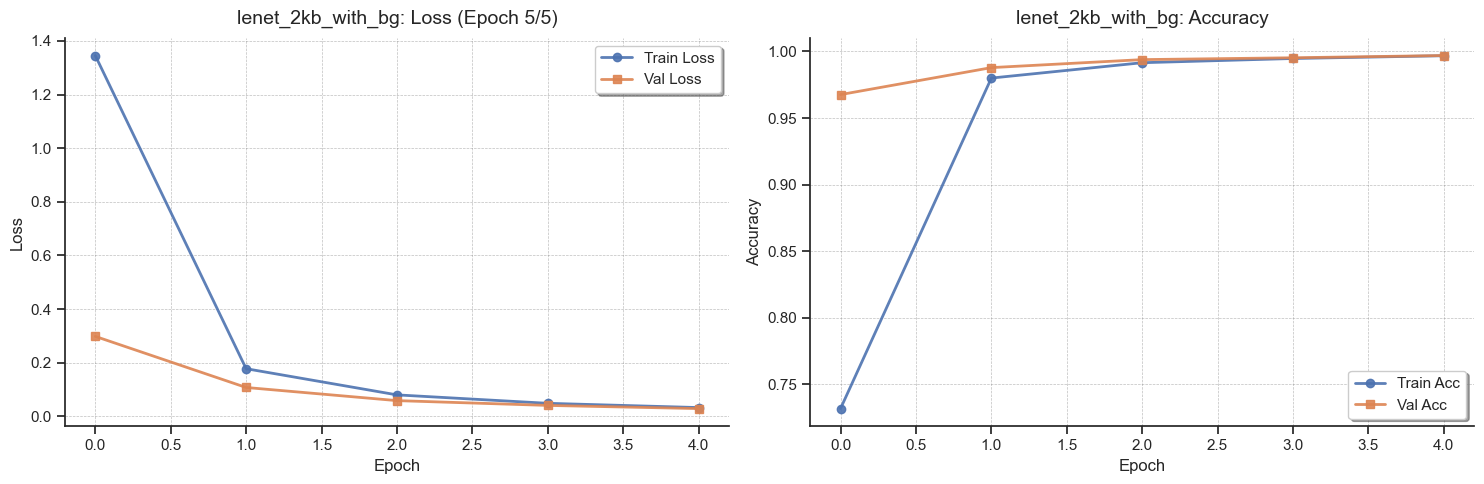

In [17]:
model_2kb_with_bg = run_test('lenet_2kb.json', model_tag="lenet_2kb_with_bg", use_bg=True, alpha=15.0)

## Блок визуализации 2KB (с bg loss)

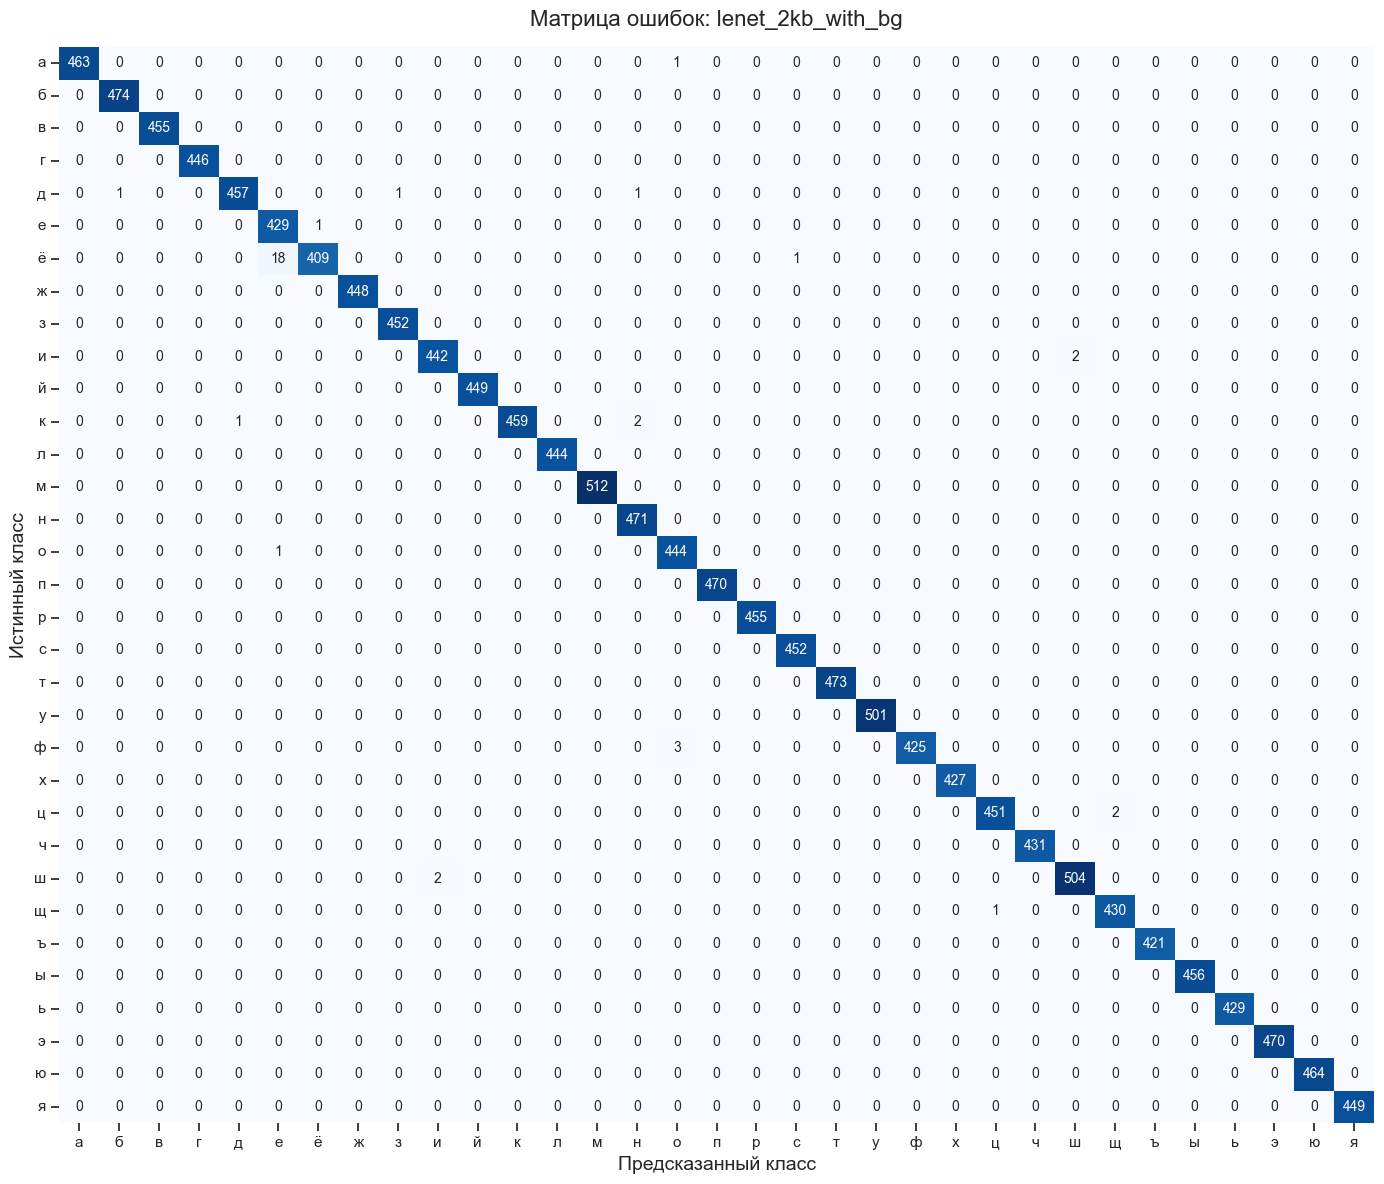

In [18]:
visualizer.plot_confusion_matrix(model_2kb_with_bg, test_loader, test_dataset, device, model_name="lenet_2kb_with_bg")

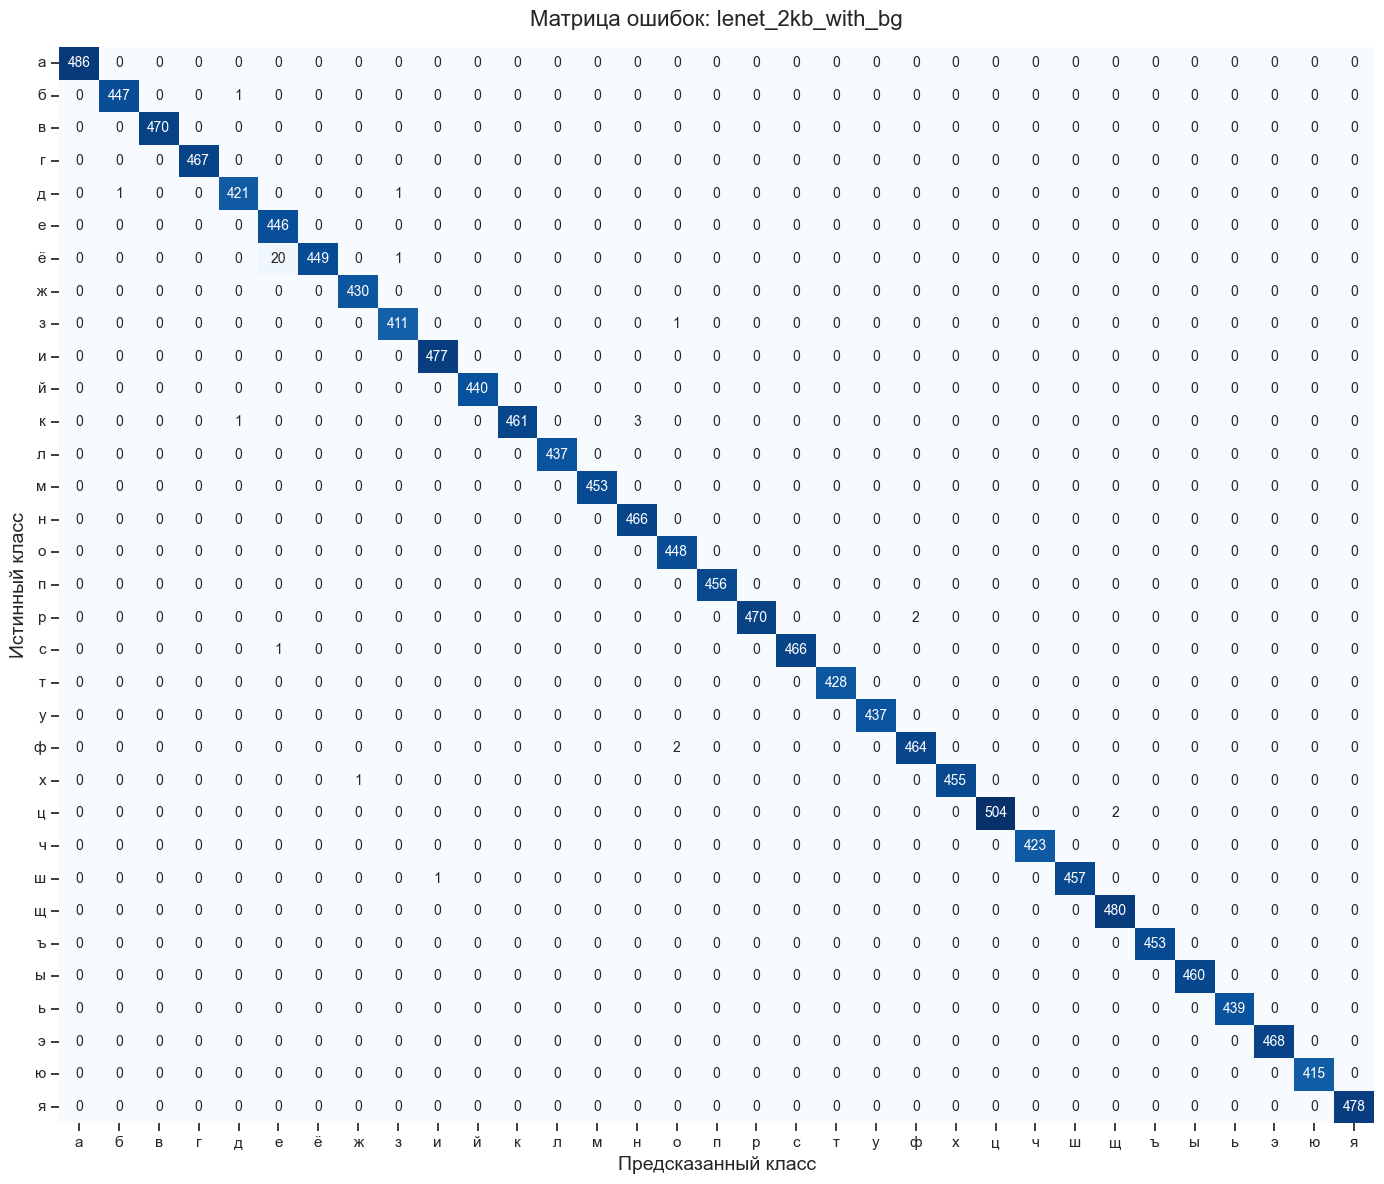

In [19]:
visualizer.plot_confusion_matrix(model_2kb_with_bg, test_loader, test_dataset, device, model_name="lenet_2kb_with_bg")